In [3]:
import pandas as pd

df = pd.read_csv('US Cancer Death Rates by State Machine.csv')
df.head()

,Unnamed: 0,2014_Rate,2014_Total,2015_Rate,2015_Total,2016_Rate,2016_Total,2017_Rate,2017_Total,2018_Rate,...,2019_Rate,2019_Total,2020_Rate,2020_Total,2021_Rate,2021_Total,2022_Rate,2022_Total,2023_Rate,2023_Total
0,AK,164.2,972.0,159.8,978.0,158.7,995.0,139.2,926.0,141.5,...,146.9,1021.0,143.7,1043.0,156.0,1093.0,145.3,1076,141.0,1070
1,AL,177.6,10286.0,175.6,10354.0,174.0,10419.0,170.0,10410.0,170.4,...,160.8,10266.0,161.6,10456.0,160.2,10429.0,154.4,10328,156.2,10568
2,AR,183.1,6546.0,185.4,6727.0,178.8,6612.0,173.6,6517.0,168.8,...,165.7,6482.0,163.8,6496.0,168.2,6516.0,168.1,6638,166.6,6653
3,AZ,142.7,11455.0,141.3,11776.0,136.8,11876.0,135.8,12008.0,131.9,...,131.1,12503.0,127.7,12676.0,134.7,12813.0,132.9,13171,127.2,13040
4,CA,144.1,58412.0,142.8,59629.0,139.7,59515.0,136.7,59516.0,135.0,...,131.6,59512.0,130.3,59778.0,132.4,59503.0,129.8,60449,128.3,60419


The dataset for this project is about cancer death rates and cancer death totals in the US from 2014 through 2023. It has the rates from each state by year as well as the total number of deaths from cancer by each year. It's interesting to see that even when the rate goes down, it doesn't necessarily mean that the total number of deaths went down. For example, from 2014-2015, Alaska's cancer death rate went down 4.4%, but the total deaths increased from 972 to 978. This isn't a major difference, but you would imagine that the total would go down if the rate also went down.

I would like to predict the cancer death rates for years into the future between states and as different regions like the midwest, east coast, etc... I think this would be a great thing to try and predict because if accurate, you could see which states/regions need more cancer research and government funding to help birng down the cancer death rate. This could also help with other things like potentially determining factors that have a higher affect when it comes to cancer death rates like weather, changes in temp, etc...

In [34]:
df = df.rename(columns={"Unnamed: 0": "State"})
print(df.isnull().sum())
df = df.dropna()

State         0
2014_Rate     1
2014_Total    1
2015_Rate     1
2015_Total    1
2016_Rate     1
2016_Total    1
2017_Rate     1
2017_Total    1
2018_Rate     1
2018_Total    1
2019_Rate     1
2019_Total    1
2020_Rate     1
2020_Total    1
2021_Rate     1
2021_Total    1
2022_Rate     0
2022_Total    0
2023_Rate     0
2023_Total    0
dtype: int64


In [35]:
from sklearn.model_selection import train_test_split

X = df[['2014_Rate', '2015_Rate', '2016_Rate','2017_Rate', '2018_Rate', '2019_Rate', '2020_Rate', '2021_Rate', '2022_Rate']]
y = df['2023_Rate']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (40, 9)
Testing size: (10, 9)


For X, I decided to use the death rates for 2014-2022 and the 2023 death rate for y so that it can crate a model that accuratley creates a linear regression model that can be used for future predictions. total deaths would be harder to use and less accurate because its so different in each state and total deaths don't take percentages into account.

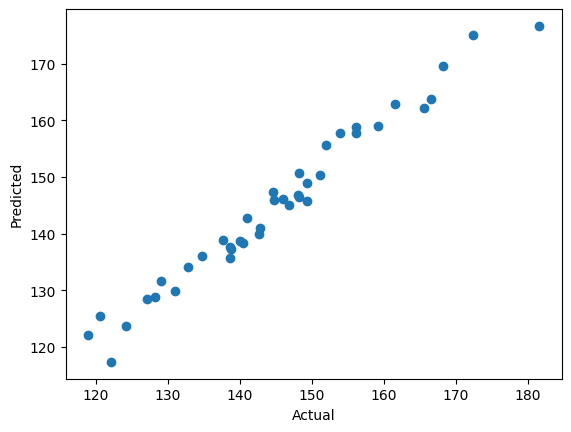

Training MSE: 5.753806238787236
Training R2: 0.9721103900867021


In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_train)
mse = mean_squared_error(y_train, predictions)
r2 = r2_score(y_train, predictions)

plt.scatter(y_train, predictions)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

print("Training MSE:", mse)
print("Training R2:", r2)

The graph shows that the model is a very good fit because the actual vs the predicted values are very similar and form a very straight line. The training r^2 value of .972 means that the X variables (all cancer death rate years leading up to 2023) are the vast majority of explaining the 2023 cancer death rate data, 97.5% in fact. This is very high and shows the viewer that the model created very accurately predicts the data for the next year. The mean squared error of 5.75 means that 

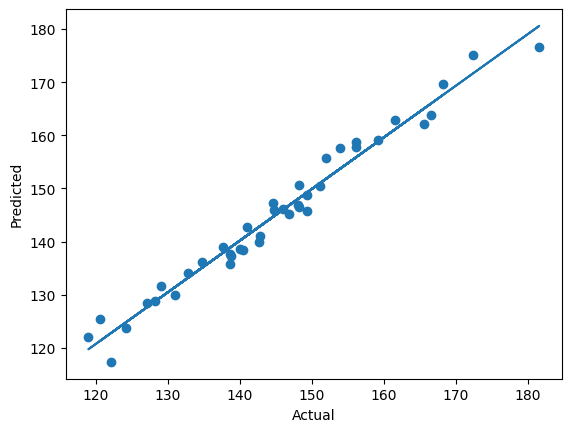

Slope:  0.9721103900867021


In [46]:
import numpy as np

plt.scatter(y_train, predictions)
slope, intercept = np.polyfit(y_train, predictions, 1)
plt.plot(y_train, slope * y_train + intercept)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()
print("Slope: ", slope)

The parameters to this data is that we don't have enough past data to take a deeper look into how much cancer death rates have dropped over a longer period of time. When you look at stocks, you can look at a short time of data to make predictions, but if you take a look at the bigger picture, you can see that the stock has more than likely gone up a significant amount. It would be nice to see more data so I can see the bigger picture of the data, but 10 years should have a pretty good prediction on how the data will change. From this data, you can interpret that cancer death rates are going down at a consistent pace because the model is a linear model and fits the data very well.

## Overview of A

After doing part A, there isn't a lot of analysis done, but setting up the data and noticing anything off or interesting about it. Something interesting that I saw was that in some cases, total death increased but the death rate decreased. That means that more people moved to that state and didn't die from cancer than people living there died from cancer. 

## Overview of B

Part B helped show how accurate the model is and how the cancer death rates changed from year to year. This is very beneficial because it shows how the US cancer death rates have been declining at a consistent rate and can help us predict how the rates will change for years to come. 

Milestone one helped me see that US cancer death rates are declining in a linear fashion which could lead to use having very accurate predictions on future rates. One challenge that I faced for this milestone was figuring out how I want to use the data and if I want to try and predict the future rates in the US in general, or by state. I learned that just because the death rate decreases, that doesn't necessarily mean that the total number of deaths also decreased. Another thing I learned was that the death rate is more consistant than the total death rate.